# Homework 4

Python 3.14.4 has been used for this homework.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [ ]:
# Skip row 1 of the sheet, since it holds the units
df = pd.read_excel("../data_flash.xlsx", skiprows=[1])
df = df.apply(pd.to_numeric, errors="coerce")

# Last column is the target, first 4 columns are the features
X = df.iloc[:, :4]
feature_names = X.columns.tolist()

print(X.shape, feature_names)

(100, 4) ['Pressure', 'Liquid flow', 'Temperature', 'Vapor flow']


In [3]:
# Apply standard scaling to the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Verify the normalization worked
print("means:", np.round(X_scaled.mean(axis=0), 6))
print("stds :", np.round(X_scaled.std(axis=0), 6))

means: [ 0.  0.  0. -0.]
stds : [1. 1. 1. 1.]


In [4]:
# Fit PCA on the scaled features
pca = PCA()
scores = pca.fit_transform(X_scaled)

# Individual variance per PC [%]
evr = pca.explained_variance_ratio_ * 100

# Cumulative variance [%]
cum = np.cumsum(evr)
n_pc = len(evr)

for i in range(n_pc):
    print(f"PC{i+1}: {evr[i]:6.2f} %  (cumulative {cum[i]:6.2f} %)")

PC1:  53.23 %  (cumulative  53.23 %)
PC2:  46.07 %  (cumulative  99.30 %)
PC3:   0.61 %  (cumulative  99.91 %)
PC4:   0.09 %  (cumulative 100.00 %)


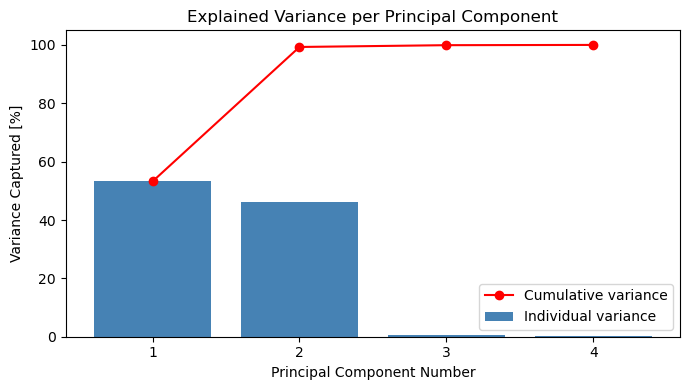

In [5]:
pcs = np.arange(1, n_pc + 1)

fig, ax = plt.subplots(figsize=(7, 4))
# Individual variance as bars
ax.bar(pcs, evr, color="steelblue", label="Individual variance")
# Cumulative variance as a line
ax.plot(pcs, cum, "o-", color="red", label="Cumulative variance")

ax.set_xlabel("Principal Component Number")
ax.set_ylabel("Variance Captured [%]")
ax.set_title("Explained Variance per Principal Component")
ax.set_xticks(pcs)
ax.legend()
plt.tight_layout()
plt.show()

## Variance Discussion

| PC  | Individual | Cumulative |
|-----|-----------|-----------|
| PC1 | 53.23 %   | 53.23 %   |
| PC2 | 46.07 %   | 99.30 %   |
| PC3 |  0.61 %   | 99.91 %   |
| PC4 |  0.09 %   | 100.00 %  |

The first two PCs already capture 99.3% of the total variance, while PC3 and PC4 are negligible. This means two latent variables describe almost all the information in the four process parameters, i.e. the original variables are strongly correlated. For dimensionality reduction, 2 components are sufficient.

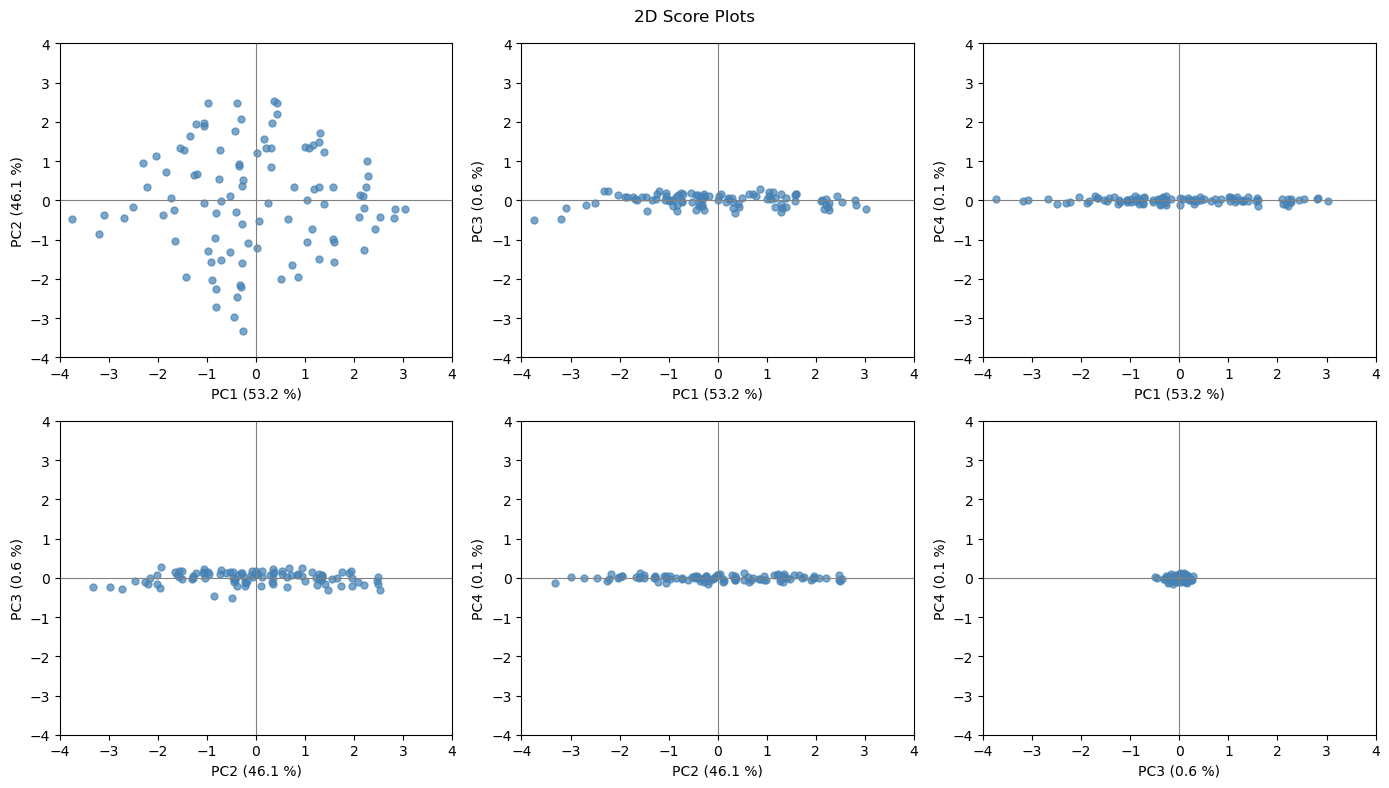

In [6]:
# All possible PC pairs, so C(4,2) = 6 combinations
pairs = list(combinations(range(n_pc), 2))

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, (i, j) in zip(axes.flat, pairs):
    ax.scatter(scores[:, i], scores[:, j], s=25, alpha=0.7, color="steelblue")
    ax.axhline(0, color="grey", lw=0.8)
    ax.axvline(0, color="grey", lw=0.8)
    ax.set_xlabel(f"PC{i+1} ({evr[i]:.1f} %)")
    ax.set_ylabel(f"PC{j+1} ({evr[j]:.1f} %)")
    ax.set_xlim(-4,4)
    ax.set_ylim(-4,4)

fig.suptitle("2D Score Plots")
plt.tight_layout()
plt.show()

## Dicussion Score Plots

The score plots show how strongly each sample loads on each PC. The PC1 vs PC2 plot is the only informative one, together they hold 99.3% of the variance. The samples spread out broadly with no distinct clusters or outliers, indicating well-behaved process data. Any plot involving PC3 or PC4 collapses the points onto a thin band, since those components carry almost no variance. 

Overall we can conclude that the four operating variables are strongly correlated and therefore reduce to two latent dimensions, with PC1 and PC2 together describing 99.3% of the dataset.